# 2. From ECG to HR and simple HRV (Principles: vagal tone, RSA)

**Exercise:** 
1. Compute RMSSD and HF power during baseline vs stress masks. 
2. Describe which increases/decreases and why (vagal withdrawal during stress → lower RMSSD/HF).

---

gpt-5: RMSSD reflects short-term beat-to-beat variability driven largely by vagal (parasympathetic) influence; HF power (0.15–0.40 Hz) indexes respiratory sinus arrhythmia and parasympathetic activity. During baseline, vagal tone is higher, so RMSSD and HF should be higher. Under stress, vagal withdrawal and sympathetic dominance reduce short-term variability, so RMSSD and HF decrease relative to baseline

In [1]:
import os
import pickle

import numpy as np
import pandas as pd

import neurokit2 as nk

import matplotlib.pyplot as plt

from scipy.signal import find_peaks, welch
from scipy.interpolate import interp1d

In [2]:
def load_wesad_subject(pkl_path: str):
    """Return dict with 'signal', 'label', plus any metadata present."""
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')  # WESAD often needs latin1
    # Normalize a few expected top-level keys if available
    out = {'raw': data}
    # Try common patterns
    for k in ['signal', 'signals', 'data']:
        if k in data:
            out['signal'] = data[k]
            break
    if 'label' in data:
        out['label'] = data['label']
    elif 'labels' in data:
        out['label'] = data['labels']
    return out

def summarize_structure(s):
    print("Top-level keys:", list(s['raw'].keys()))
    sig = s.get('signal', {})
    print("Signal namespaces:", list(sig.keys()))
    for ns, v in sig.items():
        if isinstance(v, dict):
            print(f"  [{ns}] channels:", list(v.keys()))
            for ch, arr in v.items():
                try:
                    print(f"    - {ch}: shape={np.array(arr).shape}, dtype={np.array(arr).dtype}")
                except Exception:
                    print(f"    - {ch}: (non-array)")
    if 'label' in s:
        lab = np.array(s['label']).squeeze()
        print("Labels shape:", lab.shape, "| unique:", np.unique(lab))

In [3]:
path_to_pkl = '../../../roeh-health/data/WESAD/per_subject/S7/S7.pkl'
S = load_wesad_subject(path_to_pkl)
summarize_structure(S)

Top-level keys: ['signal', 'label', 'subject']
Signal namespaces: ['chest', 'wrist']
  [chest] channels: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
    - ACC: shape=(3666600, 3), dtype=float64
    - ECG: shape=(3666600, 1), dtype=float64
    - EMG: shape=(3666600, 1), dtype=float64
    - EDA: shape=(3666600, 1), dtype=float64
    - Temp: shape=(3666600, 1), dtype=float32
    - Resp: shape=(3666600, 1), dtype=float64
  [wrist] channels: ['ACC', 'BVP', 'EDA', 'TEMP']
    - ACC: shape=(167616, 3), dtype=float64
    - BVP: shape=(335232, 1), dtype=float64
    - EDA: shape=(20952, 1), dtype=float64
    - TEMP: shape=(20952, 1), dtype=float64
Labels shape: (3666600,) | unique: [0 1 2 3 4 5 6 7]


In [7]:
S

{'raw': {'signal': {'chest': {'ACC': array([[ 1.06960011, -0.014     ,  1.4612    ],
           [ 1.06539989, -0.01020002,  1.42219996],
           [ 1.06539989,  0.00419998,  1.32019997],
           ...,
           [ 0.84660006, -0.10820001, -0.05739999],
           [ 0.84220004, -0.11379999, -0.08139998],
           [ 0.83340001, -0.11519998, -0.10259998]], shape=(3666600, 3)),
    'ECG': array([[-0.01922607],
           [-0.01693726],
           [-0.01615906],
           ...,
           [ 0.08638   ],
           [ 0.13993835],
           [ 0.23899841]], shape=(3666600, 1)),
    'EMG': array([[-0.04884338],
           [-0.00700378],
           [ 0.07177734],
           ...,
           [ 0.19976807],
           [ 0.22764587],
           [ 0.21807861]], shape=(3666600, 1)),
    'EDA': array([[12.50686646],
           [12.46871948],
           [12.50686646],
           ...,
           [13.09013367],
           [13.08135986],
           [13.08021545]], shape=(3666600, 1)),
    'Temp': ar

---chest, ECG, [[-0.01922607]
 [-0.01693726]
 [-0.01615906]
 ...
 [ 0.08638   ]
 [ 0.13993835]
 [ 0.23899841]]
[-0.01922607 -0.01693726 -0.01615906 ...  0.08638     0.13993835
  0.23899841]
[     82     177     263 ... 3666191 3666277 3666443]
Detected 18567 R-peaks from chest:ECG. RR count=18394
Time-domain HRV: {'SDNN_ms': np.float64(426.8829018876975), 'RMSSD_ms': np.float64(698.4470516017469), 'pNN50_%': np.float64(98.03185994671885)}
Freq-domain HRV: {'LF': np.float64(0.0051875486234314455), 'HF': np.float64(0.04114562090390898), 'LF_HF': np.float64(0.12607778202074985)}


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_76873/1728355619.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], fxx[idx])


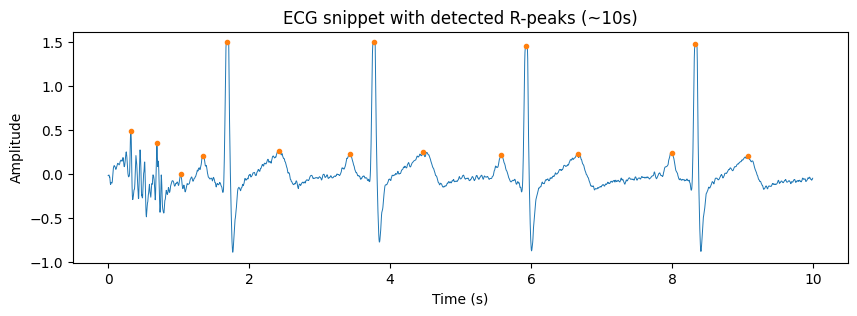

In [23]:
def rr_from_ecg(ecg, fs, min_rr=0.3, max_rr=2.0):
    """Very simple R-peak detection + RR intervals (seconds)."""
    # crude normalization
    x = (ecg - np.median(ecg)) / (np.std(ecg) + 1e-9)
    # find peaks with a refractory period ~min_rr
    peaks, _ = find_peaks(x, distance=int(min_rr*fs), prominence=np.std(x)*0.5)
    rr = np.diff(peaks) / fs  # seconds
    rr = rr[(rr > min_rr) & (rr < max_rr)]
    return peaks, rr

def hrv_time(rr):
    """Basic time-domain HRV: SDNN, RMSSD, pNN50."""
    rr_ms = rr * 1000.0
    sdnn = np.std(rr_ms, ddof=1)
    diff = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff**2))
    pnn50 = np.mean(np.abs(diff) > 50.0) * 100.0
    return {'SDNN_ms': sdnn, 'RMSSD_ms': rmssd, 'pNN50_%': pnn50}

def hrv_freq(rr, fs_interp=4.0):
    """Welch PSD on interpolated tachogram → LF/HF power."""
    # build time axis and interpolate to even sampling
    t = np.cumsum(rr)
    t = t - t[0]
    rr_series = rr
    f = interp1d(t, rr_series, kind='linear', fill_value="extrapolate")
    t_even = np.arange(0, t[-1], 1.0/fs_interp)
    rr_even = f(t_even)
    rr_even = (rr_even - np.mean(rr_even))  # detrend
    fxx, pxx = welch(rr_even, fs=fs_interp, nperseg=min(256, len(rr_even)))
    # integrate bands (Hz): LF 0.04–0.15, HF 0.15–0.40
    def band_power(fb):
        idx = np.logical_and(fxx >= fb[0], fxx < fb[1])
        return np.trapz(pxx[idx], fxx[idx])
    lf = band_power((0.04, 0.15))
    hf = band_power((0.15, 0.40))
    return {'LF': lf, 'HF': hf, 'LF_HF': (lf / hf) if hf > 0 else np.nan}

# --- pick ECG from chest or BVP from wrist as proxy if ECG missing ---
sig = S.get('signal', {})
ecg = None; fs_ecg = None
  
# Heuristic channel search
for ns in ['chest', 'wrist']:
    if ns in sig:
        for ch in sig[ns]:
            name = ch.lower()
            if 'ecg' in name:
                print(f"---{ns}, {ch}, {sig[ns][ch]}")
                ecg = np.asarray(sig[ns][ch]).squeeze()
                print(ecg)
                # If sampling rate metadata not present, set a reasonable guess; or fetch from your dataset readme.
                fs_ecg = 256.0  # TODO: replace with actual fs if known in your copy
                source = f"{ns}:{ch}"
                break
    if ecg is not None:
        break

if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    print(peaks)
    print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}")
    print("Time-domain HRV:", hrv_time(rr))
    print("Freq-domain HRV:", hrv_freq(rr))
    # Quick visualization
    t_ecg = np.arange(len(ecg))/fs_ecg
    plt.figure(figsize=(10,3))
    plt.plot(t_ecg[:10*int(fs_ecg)], ecg[:10*int(fs_ecg)], lw=0.7)
    pk = peaks[peaks < 10*fs_ecg]
    plt.plot(t_ecg[pk], ecg[pk], 'o', ms=3)
    plt.title("ECG snippet with detected R-peaks (~10s)")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.show()
else:
    print("No ECG channel found. If available, you can use wrist BVP to estimate HR (less ideal for HRV).")